# Assignment 2 — Data Wrangling and Exploratory Analysis

Author: niyonkuru_222006682@stud.ur.ac.rw

**Question explored:** which passenger groups on the Titanic (by class, sex, and age) were most likely to survive?

This notebook also satisfies the Day 3 take-home (load + schema report, two non-trivial Pandas transforms) — see `reports/day03-pandas.md` for that short reflection, and `reports/weekend-a2-report.md` for the full write-up.

## Task 1 — Dataset Selection and Schema Report

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/titanic.csv")
print("shape:", df.shape)
print("columns:", list(df.columns))
print(df.dtypes)

shape: (891, 15)
columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object


In [2]:
print("--- null counts ---")
print(df.isna().sum())
print("\n--- unique-value counts ---")
print(df.nunique())

--- null counts ---
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

--- unique-value counts ---
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


**Source:** [seaborn-data/titanic.csv](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv), a cleaned-up copy of the classic Titanic passenger manifest maintained in the [mwaskom/seaborn-data](https://github.com/mwaskom/seaborn-data) GitHub repo.

**License:** the seaborn-data repo is distributed under the BSD-3-Clause license (same as seaborn itself); the underlying passenger records are historical public-domain data widely redistributed for education (this is the same dataset behind the well-known Kaggle Titanic competition).

**Why this dataset:** 891 rows, well above the 200-row minimum; a genuine mix of numeric columns (`age`, `fare`, `sibsp`, `parch`) and categorical columns (`sex`, `embarked`, `class`, `who`, `deck`); real, non-trivial missingness (`age`, `deck`, `embarked`) that forces deliberate cleaning decisions rather than a synthetic toy case; and enough structure (class, sex, age, fare) to support a real groupby/pivot analysis with a clear, checkable finding.

## Task 2 — Data Cleaning

In [3]:
clean = df.copy()

# 1. Missing values
# age (177 missing): impute with the median age of the passenger's own
# pclass+sex group, since age correlates strongly with both (e.g. 1st-class
# passengers skew older) — a single global median would flatten that signal.
clean["age"] = clean.groupby(["pclass", "sex"])["age"].transform(
    lambda s: s.fillna(s.median())
)

# deck (688/891 = 77% missing): too sparse to impute meaningfully — any fill
# strategy would be mostly guessing, so we drop the column outright.
clean = clean.drop(columns=["deck"])

# embarked / embark_town (2 missing, same 2 rows): only 0.2% of the data,
# so we drop those 2 rows rather than invent a boarding port for them.
clean = clean.dropna(subset=["embarked"])

# alive is a yes/no string that duplicates the survived column (0/1) — drop
# the redundant copy to avoid two columns encoding the same fact.
clean = clean.drop(columns=["alive"])

print("shape after handling missing values:", clean.shape)
print(clean.isna().sum().sum(), "missing values remain")

shape after handling missing values: (889, 13)
0 missing values remain


In [4]:
# 2. Dtype fixes
# class has a real order (First > Second > Third) that plain object/category
# dtype doesn't encode — make it an ordered categorical so sorts and
# comparisons behave correctly.
clean["class"] = pd.Categorical(clean["class"], categories=["First", "Second", "Third"], ordered=True)

# low-cardinality string columns -> category dtype: same information, less
# memory, and pandas groupby/plot operations treat them as categorical.
for col in ["sex", "embarked", "who", "embark_town"]:
    clean[col] = clean[col].astype("category")

print(clean.dtypes)

survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who            category
adult_male         bool
embark_town    category
alone              bool
dtype: object


In [5]:
# 3. Duplicate rows
n_dupes = clean.duplicated().sum()
print(f"{n_dupes} fully-duplicate rows found")

# Decision: keep them, don't drop. This trimmed dataset has no passenger-
# level identifier (no name, ticket number, or passenger id survived the
# original export) — it only keeps class/sex/age/fare/etc. With just those
# columns, two different real passengers (e.g. two 3rd-class men, age 22,
# traveling alone, fare 7.25, embarked at Southampton) can legitimately end
# up with an identical row. Dropping them would silently delete real
# passengers, so we document the ambiguity instead of guessing.

118 fully-duplicate rows found


## Task 3 — Feature Engineering with GroupBy and Merge

In [6]:
print("shape before groupby+merge:", clean.shape)

# GroupBy aggregation: survival rate and average fare per (pclass, sex)
# group, useful because both class and sex turn out to be the strongest
# predictors of survival in this dataset (see Task 1 markdown / charts).
group_stats = clean.groupby(["pclass", "sex"], observed=True).agg(
    group_survival_rate=("survived", "mean"),
    group_avg_fare=("fare", "mean"),
).reset_index()

# Merge the two aggregate stats back onto every passenger row so each row
# carries "how did people like me do" alongside its own individual values.
featured = clean.merge(group_stats, on=["pclass", "sex"], how="left")

print("shape after groupby+merge:", featured.shape)
group_stats

shape before groupby+merge: (889, 13)


shape after groupby+merge: (889, 15)


,pclass,sex,group_survival_rate,group_avg_fare
0,1,female,0.967391,106.693750
1,1,male,0.368852,67.226127
2,2,female,0.921053,21.970121
3,2,male,0.157407,19.741782
4,3,female,0.500000,16.118810
5,3,male,0.135447,12.661633


In [7]:
print("shape before pivot:", featured.shape)

# Pivot/reshape: survival rate as a class x sex grid, directly answering
# "which class-sex combination survived best/worst?" — the shape a groupby
# Series can't show at a glance, but a 2D table can.
survival_pivot = featured.pivot_table(index="class", columns="sex", values="survived", aggfunc="mean", observed=True)

print("pivot table shape:", survival_pivot.shape, "(featured dataframe itself is unchanged by this reshape)")
survival_pivot

shape before pivot: (889, 15)
pivot table shape: (3, 2) (featured dataframe itself is unchanged by this reshape)


sex,female,male
class,,
First,0.967391,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


## Task 4 — NumPy-Based Computation

In [8]:
fare_arr = featured["fare"].to_numpy()

# Vectorized z-score (standardization): (x - mean) / std, computed on the
# whole array at once via broadcasting — no explicit Python loop. This is
# the kind of per-element rescaling that's awkward to express cleanly with
# plain Pandas arithmetic once you also want the underlying array stats.
fare_mean = fare_arr.mean()
fare_std = fare_arr.std()
fare_zscore = (fare_arr - fare_mean) / fare_std

print("mean:", fare_zscore.mean())
print("std:", fare_zscore.std())
print("min:", fare_zscore.min())
print("max:", fare_zscore.max())

featured["fare_zscore"] = fare_zscore

mean: 1.3987061727561027e-16
std: 1.0
min: -0.6462044460638905
max: 9.668550782149426


## Task 5 — Exploratory Visualization

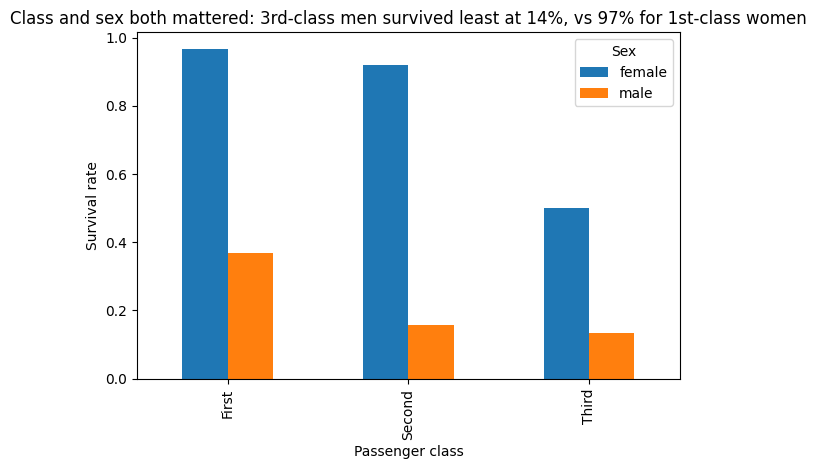

In [9]:
import matplotlib.pyplot as plt
import os

os.makedirs("../reports", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
survival_pivot.plot(kind="bar", ax=ax)
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_title("Class and sex both mattered: 3rd-class men survived least at 14%, vs 97% for 1st-class women")
ax.legend(title="Sex")
fig.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

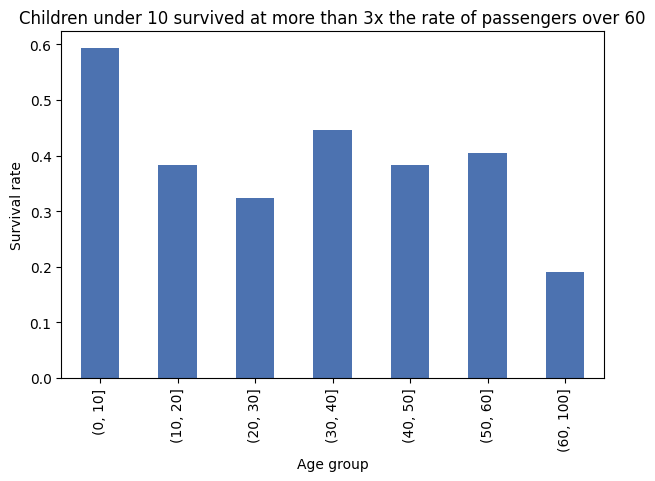

In [10]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 100]
featured["age_group"] = pd.cut(featured["age"], bins=age_bins)
age_survival = featured.groupby("age_group", observed=True)["survived"].mean()

fig, ax = plt.subplots(figsize=(7, 4.5))
age_survival.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Age group")
ax.set_ylabel("Survival rate")
ax.set_title("Children under 10 survived at more than 3x the rate of passengers over 60")
fig.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6 — Cleaned Dataset

In [11]:
os.makedirs("../data/processed", exist_ok=True)
featured.to_csv("../data/processed/titanic_cleaned.csv", index=False)
print("saved:", featured.shape)
featured.head()

saved: (889, 17)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone,group_survival_rate,group_avg_fare,fare_zscore,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,False,0.135447,12.661633,-0.500240,"(20, 30]"
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False,0.967391,106.693750,0.788947,"(30, 40]"
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True,0.500000,16.118810,-0.486650,"(20, 30]"
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,False,0.967391,106.693750,0.422861,"(30, 40]"
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,True,0.135447,12.661633,-0.484133,"(30, 40]"
